# **Introduction of the dataset**
The dataset used in this analysis belongs to an online learning platform (EduPro). It consists of multiple related tables that capture diffrent aspects of the platform such as users, courses, instructors and transactions.

### The main objective of the dataset is to analyze:

*   User behavior
*   Course engagement
*   Revenue generation

*   Learning patterns

**Tables in the Dataset**

**1. Users Table -** Contains details about platform users.

**Attributes:**


*   UserID = Unique identifier for each user
*   Name = Name of the user


*   Email = User email
*   Age = Age of the user

Used to understand user demographics.



**2.Courses Table -** Contains information about courses available on the platform

Attributes:


*   CourseID = Unique Course identifier

*   CourseName = Name of the course

*   Category = Course Domain
*   Duration = Length of course


*   Rating = Course Rating


*   InstructorID = Linked instructor

Used to analyze course popularity and quality.




**3.Teacher table**- Contains Teacher related information

Attributes:



*   TeacherID = Unique teacher ID

*   Teacher Name = Name of teacher
*   Experience = Teaching experience


*   Expertise = Domain specialization


*   Teacher rating = Ratings of teacher

Helps eveluate teacher contribution.

**4. Transaction Table** - Conatins purchase/enrollment data

Attributes:



*   TransactionID = Unique Transaction

*   UserID = Linked user

*   CourseID = Purchased course
*   Amount = Payment made


*   PaymentMethod = Mode of Payment


*   PaymentMethod = Mode of Payment



This is core table for analysis



# **Data Importing**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# **Load Dataset**

In [ ]:
path="/content/EduPro Online Platform.xlsx"

In [ ]:
users = pd.read_excel(path, sheet_name="Users")
teachers = pd.read_excel(path, sheet_name="Teachers")
courses = pd.read_excel(path, sheet_name="Courses")
transactions = pd.read_excel(path, sheet_name="Transactions")

In [ ]:
print(users.head())

   UserID        UserName  Age  Gender                             Email
0  U00001    wilsonjordan   15    Male            patricia27@hotmail.com
1  U00002        angela22   29  Female             hallrandy@hotmail.com
2  U00003  morrisonamanda   33  Female               ganderson@yahoo.com
3  U00004       fthornton   23  Female  christensencatherine@outlook.com
4  U00005  fostergeoffrey   21    Male            karenfuentes@yahoo.com


In [ ]:
print(teachers.head())

  TeacherID         TeacherName  Age  Gender          Expertise  \
0   TC00001  Leonard Montgomery   44  Female      Cybersecurity   
1   TC00002            Jill Day   32  Female  Digital Marketing   
2   TC00003        Amber Torres   32    Male             Design   
3   TC00004        Kristi Scott   34  Female   Machine Learning   
4   TC00005      David Williams   34    Male            Finance   

   YearsOfExperience  TeacherRating  
0                  6           3.24  
1                  9           4.14  
2                  4           1.56  
3                  9           4.39  
4                  2           3.11  


In [ ]:
print(courses.head())

  CourseID              CourseName CourseCategory CourseType   CourseLevel  \
0  CR00001           Python Basics    Programming       Paid      Beginner   
1  CR00002        Java Programming    Programming       Free  Intermediate   
2  CR00003       C++ for Beginners    Programming       Free      Beginner   
3  CR00004         Advanced Python    Programming       Free      Beginner   
4  CR00005  Full Stack Development    Programming       Free      Beginner   

   CoursePrice  CourseDuration  CourseRating  
0       472.28           11.00          4.74  
1         0.00           37.70          2.43  
2         0.00           19.53          3.85  
3         0.00           45.13          2.88  
4         0.00           28.68          1.28  


In [ ]:
print(transactions.head())

  TransactionID  UserID CourseID TransactionDate  Amount  PaymentMethod  \
0       TT00001  U00003  CR00016      2025-10-25     0.0         PayPal   
1       TT00002  U00003  CR00037      2025-01-13     0.0         PayPal   
2       TT00003  U00003  CR00019      2025-03-28     0.0  Bank Transfer   
3       TT00004  U00004  CR00048      2025-06-02     0.0  Bank Transfer   
4       TT00005  U00004  CR00060      2025-08-10     0.0         PayPal   

  TeacherID  
0   TC00040  
1   TC00040  
2   TC00040  
3   TC00040  
4   TC00042  


In [ ]:
print("Dataset Shape:", users.shape)

Dataset Shape: (3000, 5)


In [ ]:
print("Dataset Shape:", teachers.shape)

Dataset Shape: (60, 7)


In [ ]:
print("Dataset Shape:", courses.shape)

Dataset Shape: (60, 8)


In [ ]:
print("Dataset Shape:", transactions.shape)

Dataset Shape: (10000, 7)


# **Data PreProcessing**
To understand the structure of the data, detect missing values and identify datatypes.

**Data Inspection**

In [ ]:
# Checking the information of the datset
users.info()
print()
teachers.info()
print()
courses.info()
print()
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   UserID    3000 non-null   object
 1   UserName  3000 non-null   object
 2   Age       3000 non-null   int64 
 3   Gender    3000 non-null   object
 4   Email     3000 non-null   object
dtypes: int64(1), object(4)
memory usage: 117.3+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TeacherID          60 non-null     object 
 1   TeacherName        60 non-null     object 
 2   Age                60 non-null     int64  
 3   Gender             60 non-null     object 
 4   Expertise          60 non-null     object 
 5   YearsOfExperience  60 non-null     int64  
 6   TeacherRating      60 non-null     float64
dtypes: float64(1), int64(2), object(4)
m

In [ ]:
# Getting the stats summary of the dataset
print("Users")
print(users.describe())
print()
print("Teachers")
print(teachers.describe())
print()
print("Courses")
print(courses.describe())
print()
print("Transactions")
print(transactions.describe())
print()

Users
               Age
count  3000.000000
mean     24.974333
std       6.046475
min      15.000000
25%      20.000000
50%      25.000000
75%      30.000000
max      35.000000

Teachers
             Age  YearsOfExperience  TeacherRating
count  60.000000          60.000000      60.000000
mean   38.450000           6.283333       3.125000
std     7.703015           4.715972       0.949797
min    27.000000           1.000000       1.050000
25%    32.000000           3.000000       2.487500
50%    36.500000           6.000000       3.275000
75%    46.250000           8.000000       3.827500
max    50.000000          24.000000       4.970000

Courses
       CoursePrice  CourseDuration  CourseRating
count    60.000000       60.000000     60.000000
mean     92.986333       27.632500      3.097833
std     153.601506       16.092578      1.171232
min       0.000000        1.200000      1.130000
25%       0.000000       14.500000      2.107500
50%       0.000000       28.505000      3.065000
75

# **Data Merging**

In [ ]:
# Merging all tables
df = transactions.merge(users, on="UserID")
df = df.merge(courses, on="CourseID")
df = df.merge(teachers, on="TeacherID")

In [ ]:
# Checking merged dataset
df.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,UserName,Age_x,Gender_x,...,CourseLevel,CoursePrice,CourseDuration,CourseRating,TeacherName,Age_y,Gender_y,Expertise,YearsOfExperience,TeacherRating
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040,morrisonamanda,33,Female,...,Intermediate,0.0,42.68,4.72,Kimberly Miller,49,Male,Cybersecurity,24,4.58
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040,morrisonamanda,33,Female,...,Intermediate,0.0,33.93,3.45,Kimberly Miller,49,Male,Cybersecurity,24,4.58
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040,morrisonamanda,33,Female,...,Advanced,0.0,18.00,2.98,Kimberly Miller,49,Male,Cybersecurity,24,4.58
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040,fthornton,23,Female,...,Beginner,0.0,42.70,3.64,Kimberly Miller,49,Male,Cybersecurity,24,4.58
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042,fthornton,23,Female,...,Beginner,0.0,8.95,2.14,Yolanda Levine,49,Female,Machine Learning,21,4.97


In [ ]:
# Checking the columns of the dataset
df.columns

Index(['TransactionID', 'UserID', 'CourseID', 'TransactionDate', 'Amount',
       'PaymentMethod', 'TeacherID', 'UserName', 'Age_x', 'Gender_x', 'Email',
       'CourseName', 'CourseCategory', 'CourseType', 'CourseLevel',
       'CoursePrice', 'CourseDuration', 'CourseRating', 'TeacherName', 'Age_y',
       'Gender_y', 'Expertise', 'YearsOfExperience', 'TeacherRating'],
      dtype='object')

In [ ]:
# Renaming the required columns
df.rename(columns={"Age_x":"UserAge", "Gender_x":"UserGender", "Age_y":"TeacherAge", "Gender_y":"TeacherGender"},inplace=True)

In [ ]:
# Checking the columns again
df.columns

Index(['TransactionID', 'UserID', 'CourseID', 'TransactionDate', 'Amount',
       'PaymentMethod', 'TeacherID', 'UserName', 'UserAge', 'UserGender',
       'Email', 'CourseName', 'CourseCategory', 'CourseType', 'CourseLevel',
       'CoursePrice', 'CourseDuration', 'CourseRating', 'TeacherName',
       'TeacherAge', 'TeacherGender', 'Expertise', 'YearsOfExperience',
       'TeacherRating'],
      dtype='object')

### **Handling Missing Values and Outliers**

In [ ]:
# Checking for null values
df.isnull().sum()

,0
TransactionID,0
UserID,0
CourseID,0
TransactionDate,0
Amount,0
PaymentMethod,0
TeacherID,0
UserName,0
UserAge,0
UserGender,0


In [ ]:
# Checking the information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      10000 non-null  object        
 1   UserID             10000 non-null  object        
 2   CourseID           10000 non-null  object        
 3   TransactionDate    10000 non-null  datetime64[ns]
 4   Amount             10000 non-null  float64       
 5   PaymentMethod      10000 non-null  object        
 6   TeacherID          10000 non-null  object        
 7   UserName           10000 non-null  object        
 8   UserAge            10000 non-null  int64         
 9   UserGender         10000 non-null  object        
 10  Email              10000 non-null  object        
 11  CourseName         10000 non-null  object        
 12  CourseCategory     10000 non-null  object        
 13  CourseType         10000 non-null  object        
 14  CourseL

In [ ]:
# Deriving the statistical matrix of the dataset
df.describe()

,TransactionDate,Amount,UserAge,CoursePrice,CourseDuration,CourseRating,TeacherAge,YearsOfExperience,TeacherRating
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2025-07-01 03:50:32.640000,91.132347,24.965700,91.132347,27.509536,3.123277,44.885000,16.024100,4.087769
min,2025-01-01 00:00:00,0.000000,15.000000,0.000000,1.200000,1.130000,27.000000,1.000000,1.050000
25%,2025-04-02 00:00:00,0.000000,20.000000,0.000000,12.130000,2.140000,44.000000,7.000000,3.460000
50%,2025-06-30 00:00:00,0.000000,25.000000,0.000000,28.330000,3.110000,49.000000,21.000000,4.580000
75%,2025-09-28 00:00:00,119.040000,30.000000,119.040000,42.700000,4.110000,49.000000,24.000000,4.970000
max,2025-12-30 00:00:00,490.900000,35.000000,490.900000,49.730000,4.940000,50.000000,24.000000,4.970000
std,NaN,152.063524,6.051858,152.063524,16.011616,1.156254,6.988566,8.521783,1.069542


In [ ]:
# Checking the unique values of the dataset
df.nunique()

,0
TransactionID,10000
UserID,3000
CourseID,60
TransactionDate,358
Amount,23
PaymentMethod,3
TeacherID,60
UserName,3000
UserAge,21
UserGender,2


In [ ]:
# Checking the duplicate records
df.duplicated().sum()

np.int64(0)

# **Learner Demographic Analysis**

**Active users**

In [ ]:
# Step 1:Check the age distribution
print("Minimum Age:", df["UserAge"].min())
print("Maximum Age:", df["UserAge"].max())

print("\nAge Statistics:")
print(df["UserAge"].describe())

Minimum Age: 15
Maximum Age: 35

Age Statistics:
count    10000.000000
mean        24.965700
std          6.051858
min         15.000000
25%         20.000000
50%         25.000000
75%         30.000000
max         35.000000
Name: UserAge, dtype: float64


In [ ]:
# Step 2: Create age groups
df['UserAgeGroup'] = pd.cut(
    df['UserAge'],
    bins=[0,18,25,35],
    labels=['Teen','Young', 'Adult']
)

In [ ]:
# Step 3: Count users in each age group

age_group_counts = df["UserAgeGroup"].value_counts().sort_index()

print(age_group_counts)

UserAgeGroup
Teen     1946
Young    3255
Adult    4799
Name: count, dtype: int64


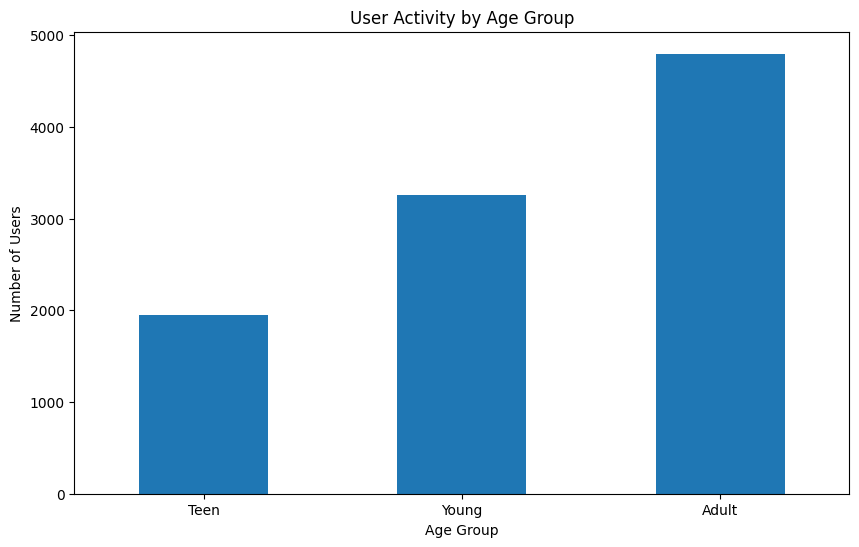

In [ ]:
# Step 4: Create a bar chart

plt.figure(figsize=(10, 6))

age_group_counts.plot(kind="bar")

plt.title("User Activity by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Users")
plt.xticks(rotation=0)

plt.show()

In [ ]:
# Step 5: Find the most active age group

most_active_group = age_group_counts.idxmax()
most_active_users = age_group_counts.max()

print("Most Active Age Group:", most_active_group)
print("Number of Users:", most_active_users)

Most Active Age Group: Adult
Number of Users: 4799


**Conclude:**
  
   

*  From the above analysis there are three age group of students is Teen,Young and adults

*  so from the above three the **Adult group** are most active on the platform which include 4799 users.


*   The second active group is young group which include 3255 users.
*   Doing the comparison between adluts and young group there is a difference between them is 1544 users.

*   From the above analysis the least active users is teen users which include only 1946 users.
*  During this analysis conclude that the most platform use by adults and least by teen.












**Enrollement pattern differ by gender**

In [ ]:
# Count number of enrollments for each gender
gender_enrollment = df["UserGender"].value_counts()

print("Enrollments by Gender:")
print(gender_enrollment)

Enrollments by Gender:
UserGender
Female    5078
Male      4922
Name: count, dtype: int64


In [ ]:
# Calculate percentage of total enrollments
gender_percentage = (
    df["UserGender"]
    .value_counts(normalize=True) * 100
)

gender_result = pd.DataFrame({
    "Number of Enrollments": gender_enrollment,
    "Percentage": gender_percentage.round(2)
})

print(gender_result)

            Number of Enrollments  Percentage
UserGender                                   
Female                       5078       50.78
Male                         4922       49.22


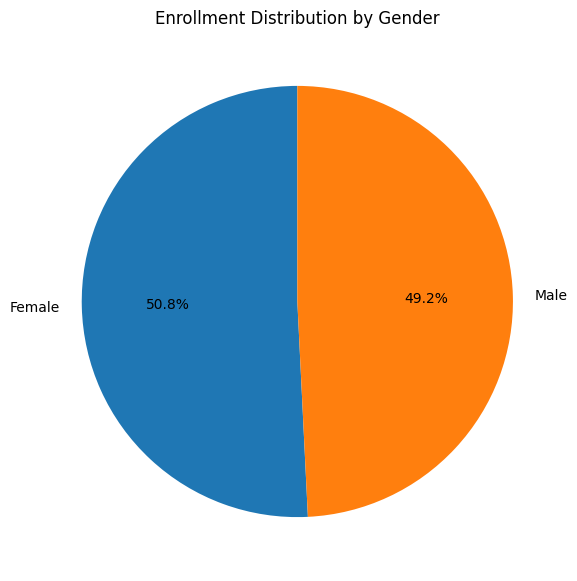

In [ ]:
plt.figure(figsize=(7, 7))

gender_enrollment.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Enrollment Distribution by Gender")
plt.ylabel("")

plt.show()

In [ ]:
most_enrolled_gender = gender_enrollment.idxmax()
highest_enrollments = gender_enrollment.max()

print("Gender with highest enrollments:", most_enrolled_gender)
print("Number of enrollments:", highest_enrollments)

Gender with highest enrollments: Female
Number of enrollments: 5078


### **Analysis:**


*   The number and percentage of enrollments were calculated for each gender.
*   The gender with the highest number of enrollments represents the largest contributor to course enrollments on the EduPro platform.


*   According to the analysis the Female users are more with 5078 of enrolles with the precentage of 50.8.

*   The male participation is slightly less than female which is the 4922 of enrolles with the percentage of 49.2.
*   There is only 1.6% of gap between female and male.


*   So it conclude that the female is more actively participate to learn.








**course categories are preferred by different learner segments**

In [ ]:
# Count enrollments for each Age Group and Course Category

category_preference = pd.crosstab(
    df["UserAgeGroup"],
    df["CourseCategory"]
)

print("Course Category Preferences by Age Group:")
display(category_preference)

Course Category Preferences by Age Group:


CourseCategory,Artificial Intelligence,Business,Cybersecurity,Data Science,Design,Digital Marketing,Finance,Machine Learning,Marketing,Programming,Project Management,Web Development
UserAgeGroup,,,,,,,,,,,,
Teen,176,155,165,167,158,167,173,153,163,150,152,167
Young,270,272,263,290,273,256,260,272,276,264,259,300
Adult,383,406,391,459,396,385,431,394,367,392,418,377


In [ ]:
# Find the category with the highest enrollments for each age group

most_preferred = category_preference.idxmax(axis=1)

print("Most Preferred Course Category by Age Group:")
print(most_preferred)

Most Preferred Course Category by Age Group:
UserAgeGroup
Teen     Artificial Intelligence
Young            Web Development
Adult               Data Science
dtype: object


In [ ]:
# Convert enrollment counts into percentages

category_percentage = category_preference.div(
    category_preference.sum(axis=1),
    axis=0
) * 100

category_percentage = category_percentage.round(2)

print("Course Category Preference (%) by Age Group:")
display(category_percentage)

Course Category Preference (%) by Age Group:


CourseCategory,Artificial Intelligence,Business,Cybersecurity,Data Science,Design,Digital Marketing,Finance,Machine Learning,Marketing,Programming,Project Management,Web Development
UserAgeGroup,,,,,,,,,,,,
Teen,9.04,7.97,8.48,8.58,8.12,8.58,8.89,7.86,8.38,7.71,7.81,8.58
Young,8.29,8.36,8.08,8.91,8.39,7.86,7.99,8.36,8.48,8.11,7.96,9.22
Adult,7.98,8.46,8.15,9.56,8.25,8.02,8.98,8.21,7.65,8.17,8.71,7.86


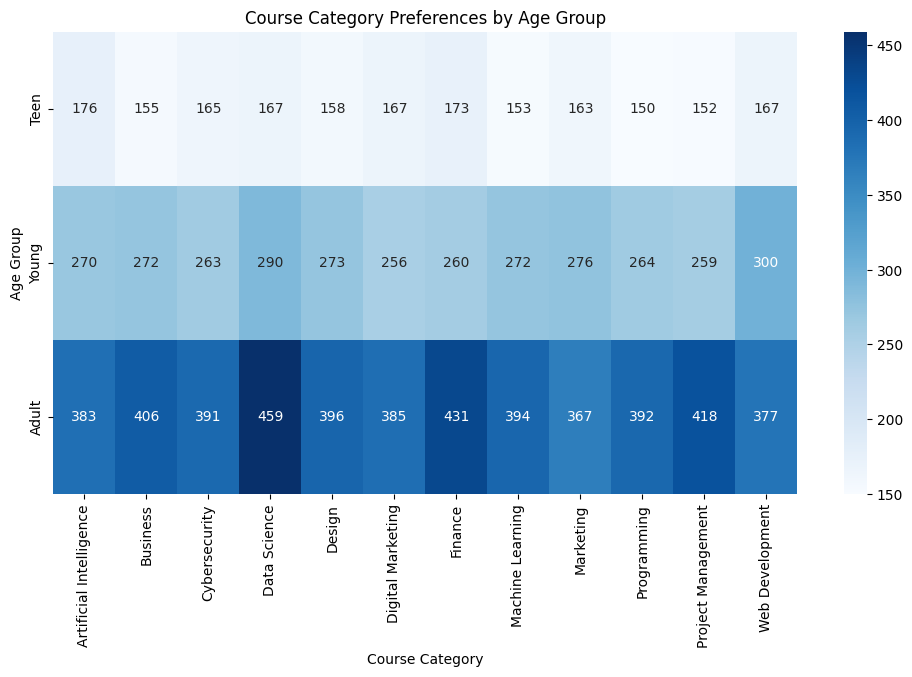

In [ ]:

import seaborn as sns

plt.figure(figsize=(12, 6))

sns.heatmap(
    category_preference,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Course Category Preferences by Age Group")
plt.xlabel("Course Category")
plt.ylabel("Age Group")

plt.show()

### **Analysis:**





Course enrollment data was analyzed across different learner age groups to

*   Course enrollment data was analyzed across different learner age groups to identify category preference.
*   The analysis shows which course categories are most popular among each age segment.


*    Most Preferred Course Category by Age Group

Teen   -  Artificial Intelligence

Young     -       Web Development

Adult      -         Data Science
     


*  The above heatmap shows the number of users of each category enroll in each course.


*   This analysis helps EduPro understand learner interests and provide personalized course recommendations and targeted marketing for different age groups.


**Beginner, intermediate, or advanced courses more popular among specific age groups**

In [ ]:
# Create Age Group × Course Level table

level_preference = pd.crosstab(
    df["UserAgeGroup"],
    df["CourseLevel"]
)

print("Course Level Preference by Age Group:")
display(level_preference)

Course Level Preference by Age Group:


CourseLevel,Advanced,Beginner,Intermediate
UserAgeGroup,,,
Teen,694,673,579
Young,1140,1173,942
Adult,1641,1727,1431


In [ ]:
# Find the most popular course level for each age group

most_popular_level = level_preference.idxmax(axis=1)

print("Most Popular Course Level by Age Group:")
display(most_popular_level)

Most Popular Course Level by Age Group:


,0
UserAgeGroup,
Teen,Advanced
Young,Beginner
Adult,Beginner


In [ ]:
# Calculate percentage distribution within each age group

level_percentage = level_preference.div(
    level_preference.sum(axis=1),
    axis=0
) * 100

level_percentage = level_percentage.round(2)

print("Course Level Preference (%) by Age Group:")
display(level_percentage)

Course Level Preference (%) by Age Group:


CourseLevel,Advanced,Beginner,Intermediate
UserAgeGroup,,,
Teen,35.66,34.58,29.75
Young,35.02,36.04,28.94
Adult,34.19,35.99,29.82


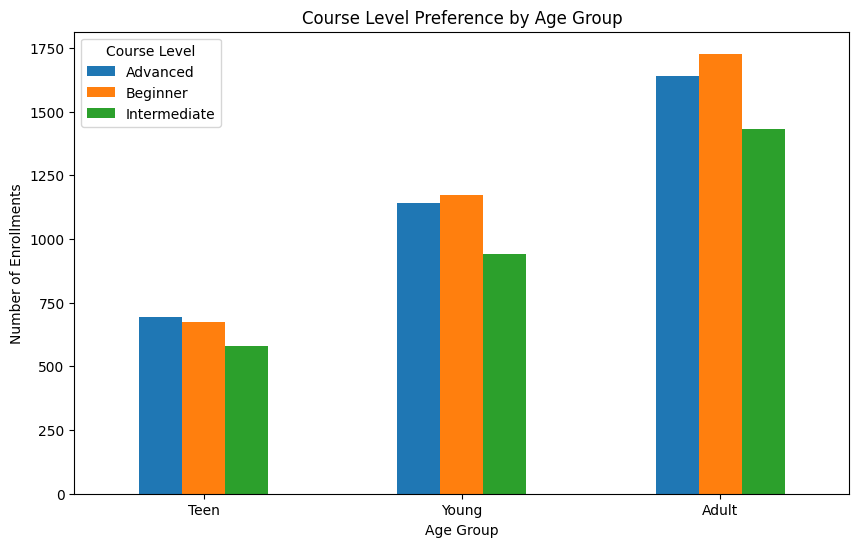

In [ ]:
# Bar chart

level_preference.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Course Level Preference by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Enrollments")
plt.xticks(rotation=0)
plt.legend(title="Course Level")

plt.show()

### Analysis:



*  Course enrollments were analyzed according to learner age groups and course difficulty levels.
*   Among the teen,young and adult they have their own course level preference.



*   Most Popular Course Level by Age Group:

Teen -	Advanced

Young	 - Beginner

Adult -	Beginner
*  According to bar chart that shows the number of group have their course level.


*   This  analysis helps EduPro understand the learning level preferred by different learner segments and can support personalized course recommendations and targeted learning strategies.









# **Enrollment Distribution Analysis**

In [ ]:

# Enrollment Count by Course Category


category_count = (
    df["CourseCategory"]
    .value_counts()
)

print("===== ENROLLMENTS BY COURSE CATEGORY =====")
display(category_count)

===== ENROLLMENTS BY COURSE CATEGORY =====


,count
CourseCategory,
Data Science,916
Finance,864
Web Development,844
Business,833
Artificial Intelligence,829
Project Management,829
Design,827
Cybersecurity,819
Machine Learning,819


In [ ]:


# Enrollment Count by Course Type


type_count = (
    df["CourseType"]
    .value_counts()
)

print("===== ENROLLMENTS BY COURSE TYPE =====")
display(type_count)

===== ENROLLMENTS BY COURSE TYPE =====


,count
CourseType,
Free,6403
Paid,3597


In [ ]:

# Enrollment Count by Course Level


level_count = (
    df["CourseLevel"]
    .value_counts()
)

print("===== ENROLLMENTS BY COURSE LEVEL =====")
display(level_count)

===== ENROLLMENTS BY COURSE LEVEL =====


,count
CourseLevel,
Beginner,3573
Advanced,3475
Intermediate,2952


In [ ]:

# Summary of Enrollment Counts


print("===== COURSE CATEGORY =====")
display(
    category_count.reset_index()
    .rename(columns={
        "CourseCategory": "Course Category",
        "count": "Enrollments"
    })
)

print("===== COURSE TYPE =====")
display(
    type_count.reset_index()
    .rename(columns={
        "CourseType": "Course Type",
        "count": "Enrollments"
    })
)

print("===== COURSE LEVEL =====")
display(
    level_count.reset_index()
    .rename(columns={
        "CourseLevel": "Course Level",
        "count": "Enrollments"
    })
)

===== COURSE CATEGORY =====


,Course Category,Enrollments
0,Data Science,916
1,Finance,864
2,Web Development,844
3,Business,833
4,Artificial Intelligence,829
5,Project Management,829
6,Design,827
7,Cybersecurity,819
8,Machine Learning,819
9,Digital Marketing,808


===== COURSE TYPE =====


,Course Type,Enrollments
0,Free,6403
1,Paid,3597


===== COURSE LEVEL =====


,Course Level,Enrollments
0,Beginner,3573
1,Advanced,3475
2,Intermediate,2952


In [ ]:
# Most Popular Category

most_popular_category = category_count.idxmax()
most_popular_count = category_count.max()

print("\n===== MOST POPULAR CATEGORY =====")
print("Category:", most_popular_category)
print("Enrollments:", most_popular_count)



===== MOST POPULAR CATEGORY =====
Category: Data Science
Enrollments: 916


In [ ]:
# Least Popular Category


least_popular_category = category_count.idxmin()
least_popular_count = category_count.min()

print("\n===== LEAST POPULAR CATEGORY =====")
print("Category:", least_popular_category)
print("Enrollments:", least_popular_count)


===== LEAST POPULAR CATEGORY =====
Category: Marketing
Enrollments: 806


In [ ]:
# Top 3 categories
top_3 = category_count.head(3)

print("===== TOP 3 MOST POPULAR CATEGORIES =====")
display(top_3.to_frame("Enrollments"))

# Bottom 3 categories
bottom_3 = category_count.tail(3).sort_values()

print("\n===== TOP 3 LEAST POPULAR CATEGORIES =====")
display(bottom_3.to_frame("Enrollments"))

===== TOP 3 MOST POPULAR CATEGORIES =====


,Enrollments
CourseCategory,
Data Science,916
Finance,864
Web Development,844



===== TOP 3 LEAST POPULAR CATEGORIES =====


,Enrollments
CourseCategory,
Marketing,806
Programming,806
Digital Marketing,808


# **Demographics × Course Preference Analysis**

In [ ]:

#  Age group vs Course category


age_category_table = pd.crosstab(
    df["UserAgeGroup"],
    df["CourseCategory"]
)

print("Age Group vs Course Category:")
display(age_category_table)

Age Group vs Course Category:


CourseCategory,Artificial Intelligence,Business,Cybersecurity,Data Science,Design,Digital Marketing,Finance,Machine Learning,Marketing,Programming,Project Management,Web Development
UserAgeGroup,,,,,,,,,,,,
Teen,176,155,165,167,158,167,173,153,163,150,152,167
Young,270,272,263,290,273,256,260,272,276,264,259,300
Adult,383,406,391,459,396,385,431,394,367,392,418,377


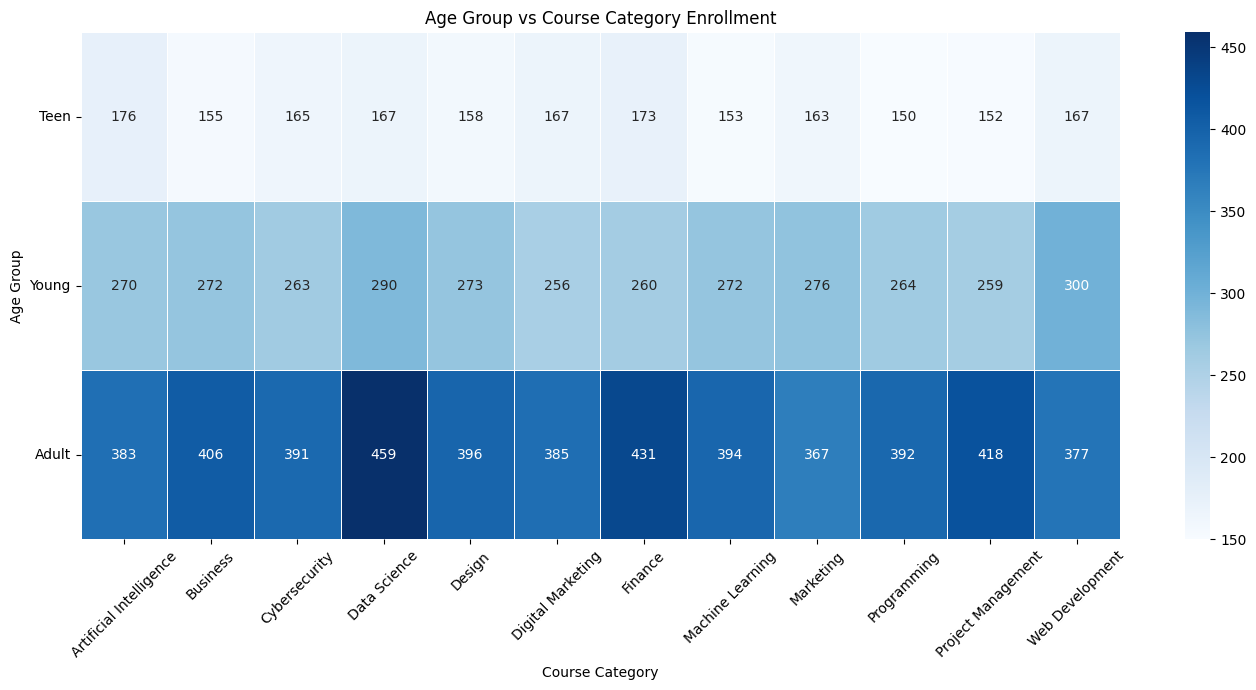

In [ ]:

#  Heatmap

plt.figure(figsize=(14, 7))

sns.heatmap(
    age_category_table,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Age Group vs Course Category Enrollment")
plt.xlabel("Course Category")
plt.ylabel("Age Group")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:

# Most Popular Category for Each Age Group


most_preferred_category = age_category_table.idxmax(axis=1)

print("Most Preferred Course Category by Age Group:")
display(most_preferred_category.to_frame("Most Preferred Category"))

Most Preferred Course Category by Age Group:


,Most Preferred Category
UserAgeGroup,
Teen,Artificial Intelligence
Young,Web Development
Adult,Data Science


In [ ]:

#  Gender vs Course Level


gender_level = pd.crosstab(
    df["UserGender"],
   df["CourseLevel"]
)

print("===== GENDER VS COURSE LEVEL =====")
display(gender_level)

===== GENDER VS COURSE LEVEL =====


CourseLevel,Advanced,Beginner,Intermediate
UserGender,,,
Female,1758,1811,1509
Male,1717,1762,1443


In [ ]:



#  Most Popular Course Level


most_popular_level = gender_level.idxmax(axis=1)

print("===== MOST POPULAR COURSE LEVEL BY GENDER =====")
display(
    most_popular_level.to_frame(
        "Most Popular Course Level"
    )
)

===== MOST POPULAR COURSE LEVEL BY GENDER =====


,Most Popular Course Level
UserGender,
Female,Beginner
Male,Beginner


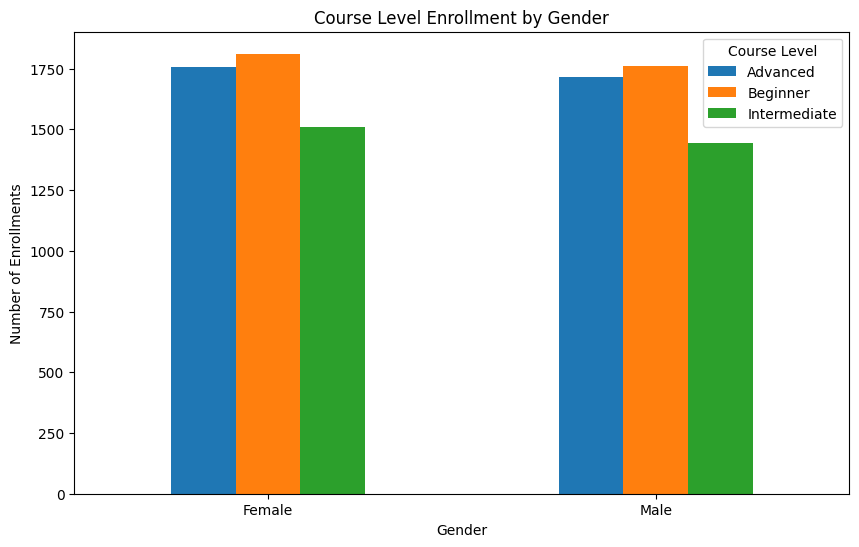

In [ ]:

#  Bar Chart


gender_level.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Course Level Enrollment by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Enrollments")
plt.xticks(rotation=0)
plt.legend(title="Course Level")

plt.show()

In [ ]:
# Course preferences by learner segment
segment_preferences = df.groupby(
    ["UserAgeGroup", "CourseCategory"],
    observed=False
).size().reset_index(name="Enrollments")

print("\nCourse Category Preferences:")
print(segment_preferences.sort_values("Enrollments", ascending=False))


Course Category Preferences:
   UserAgeGroup           CourseCategory  Enrollments
27        Adult             Data Science          459
30        Adult                  Finance          431
34        Adult       Project Management          418
25        Adult                 Business          406
28        Adult                   Design          396
31        Adult         Machine Learning          394
33        Adult              Programming          392
26        Adult            Cybersecurity          391
29        Adult        Digital Marketing          385
24        Adult  Artificial Intelligence          383
35        Adult          Web Development          377
32        Adult                Marketing          367
23        Young          Web Development          300
15        Young             Data Science          290
20        Young                Marketing          276
16        Young                   Design          273
19        Young         Machine Learning          27

In [ ]:
# Course Type preferences


course_type_preferences = df.groupby(
    ["UserAgeGroup", "CourseType"],
    observed=False
).size().reset_index(name="Enrollments")

print("\nCourse Type Preferences:")
print(course_type_preferences.sort_values("Enrollments", ascending=False))



Course Type Preferences:
  UserAgeGroup CourseType  Enrollments
4        Adult       Free         3085
2        Young       Free         2108
5        Adult       Paid         1714
0         Teen       Free         1210
3        Young       Paid         1147
1         Teen       Paid          736


In [ ]:
# Course Level preferences


course_level_preferences = df.groupby(
    ["UserAgeGroup", "CourseLevel"],
    observed=False
).size().reset_index(name="Enrollments")

print("\nCourse Level Preferences:")
print(course_level_preferences.sort_values("Enrollments", ascending=False))


Course Level Preferences:
  UserAgeGroup   CourseLevel  Enrollments
7        Adult      Beginner         1727
6        Adult      Advanced         1641
8        Adult  Intermediate         1431
4        Young      Beginner         1173
3        Young      Advanced         1140
5        Young  Intermediate          942
0         Teen      Advanced          694
1         Teen      Beginner          673
2         Teen  Intermediate          579


In [ ]:
 #Find the most preferred category for each age group


top_category = (
    df.groupby(["UserAgeGroup", "CourseCategory"], observed=False)
      .size()
      .reset_index(name="Enrollments")
      .sort_values(["UserAgeGroup", "Enrollments"], ascending=[True, False])
      .groupby("UserAgeGroup", observed=False)
      .head(1)
)

print("\nMost Preferred Course Category by Age Group:")
print(top_category)



Most Preferred Course Category by Age Group:
   UserAgeGroup           CourseCategory  Enrollments
0          Teen  Artificial Intelligence          176
23        Young          Web Development          300
27        Adult             Data Science          459


In [ ]:
 # Find the most preferred course level


top_level = (
    df.groupby(["UserAgeGroup", "CourseLevel"], observed=False)
      .size()
      .reset_index(name="Enrollments")
      .sort_values(["UserAgeGroup", "Enrollments"], ascending=[True, False])
      .groupby("UserAgeGroup", observed=False)
      .head(1)
)

print("\nMost Preferred Course Level by Age Group:")
print(top_level)


Most Preferred Course Level by Age Group:
  UserAgeGroup CourseLevel  Enrollments
0         Teen    Advanced          694
4        Young    Beginner         1173
7        Adult    Beginner         1727


In [ ]:
# Overall learner preference


overall_preferences = df.groupby(
    "CourseCategory"
).size().reset_index(name="Enrollments")

overall_preferences = overall_preferences.sort_values(
    "Enrollments",
    ascending=False
)

print("\nOverall Course Category Preferences:")
print(overall_preferences)


Overall Course Category Preferences:
             CourseCategory  Enrollments
3              Data Science          916
6                   Finance          864
11          Web Development          844
1                  Business          833
10       Project Management          829
0   Artificial Intelligence          829
4                    Design          827
2             Cybersecurity          819
7          Machine Learning          819
5         Digital Marketing          808
9               Programming          806
8                 Marketing          806


# **Behavioral Insights**

In [ ]:
# Count unique courses taken by each learner
courses_per_learner = df.groupby("UserID")["CourseID"].nunique()


In [ ]:
# Calculate average courses taken per learner
average_courses = courses_per_learner.mean()

print("Average Courses Taken per Learner:", round(average_courses, 2))

Average Courses Taken per Learner: 3.33


In [ ]:
# Count enrollments for each user
user_enrollments = df.groupby("UserID").size().reset_index(name="EnrollmentCount")

# Sort users by number of enrollments
user_enrollments = user_enrollments.sort_values(
    by="EnrollmentCount", ascending=False
)


In [ ]:
# Total enrollments
total_enrollments = user_enrollments["EnrollmentCount"].sum()

In [ ]:
# Calculate enrollment percentage for each active user
user_enrollments["EnrollmentPercentage"] = (
    user_enrollments["EnrollmentCount"] / total_enrollments * 100
)

In [ ]:
# Display top 10 active users
top_10_users = user_enrollments.head(10)

print("Top 10 Active Users:")
print(top_10_users)

# Enrollment concentration of top 10 users
top_10_concentration = top_10_users["EnrollmentCount"].sum() / total_enrollments * 100

print("\nEnrollment Concentration of Top 10 Active Users:",
      round(top_10_concentration, 2), "%")

Top 10 Active Users:
      UserID  EnrollmentCount  EnrollmentPercentage
2975  U02976               16                  0.16
17    U00018               16                  0.16
426   U00427               16                  0.16
1202  U01203               16                  0.16
2257  U02258               16                  0.16
1723  U01724               16                  0.16
338   U00339               16                  0.16
1336  U01337               16                  0.16
1542  U01543               16                  0.16
828   U00829               16                  0.16

Enrollment Concentration of Top 10 Active Users: 1.6 %


In [ ]:
#  Number of enrollments

enrollment_count = (
    df["CourseLevel"]
    .value_counts()
    .reset_index()
)

enrollment_count.columns = ["CourseLevel", "Enrollments"]

print("Beginner vs Advanced Enrollments:")
print(enrollment_count)

Beginner vs Advanced Enrollments:
    CourseLevel  Enrollments
0      Beginner         3573
1      Advanced         3475
2  Intermediate         2952


In [ ]:
# Average spending
# --------------------------------------------------
avg_spending = (
    df
    .groupby("CourseLevel")["Amount"]
    .mean()
    .reset_index()
)

avg_spending.columns = ["CourseLevel", "AverageSpending"]

print("\nAverage Spending:")
print(avg_spending)



Average Spending:
    CourseLevel  AverageSpending
0      Advanced        80.010412
1      Beginner       103.280543
2  Intermediate        89.520972


In [ ]:
# Preferred course categories
# --------------------------------------------------
category_preference = pd.crosstab(
    df["CourseLevel"],
    df["CourseCategory"]
)

print("\nCourse Category Preference:")
print(category_preference)




Course Category Preference:
CourseCategory  Artificial Intelligence  Business  Cybersecurity  \
CourseLevel                                                        
Advanced                              0       514            163   
Beginner                            500       168            179   
Intermediate                        329       151            477   

CourseCategory  Data Science  Design  Digital Marketing  Finance  \
CourseLevel                                                        
Advanced                 166     672                288      172   
Beginner                 369     155                359      348   
Intermediate             381       0                161      344   

CourseCategory  Machine Learning  Marketing  Programming  Project Management  \
CourseLevel                                                                    
Advanced                     323        498            0                 167   
Beginner                     155          0      

In [ ]:
# Preferred course types
# --------------------------------------------------
type_preference = pd.crosstab(
    df["CourseLevel"],
    df["CourseType"]
)

print("\nCourse Type Preference:")
print(type_preference)




Course Type Preference:
CourseType    Free  Paid
CourseLevel             
Advanced      2005  1470
Beginner      2395  1178
Intermediate  2003   949


In [ ]:
# Average course duration

avg_duration = (
    df
    .groupby("CourseLevel")["CourseDuration"]
    .mean()
    .reset_index()
)

print("\nAverage Course Duration:")
print(avg_duration)


Average Course Duration:
    CourseLevel  CourseDuration
0      Advanced       26.725945
1      Beginner       28.313949
2  Intermediate       27.458320


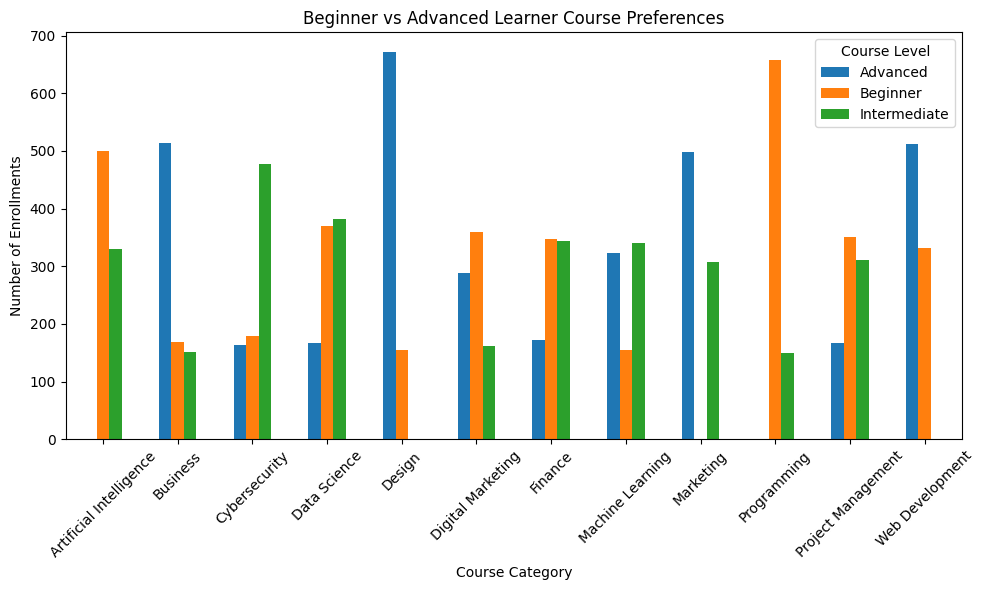

In [ ]:
#  Visualization - Category preference

category_plot = pd.crosstab(
   df["CourseCategory"],
    df["CourseLevel"]
)

category_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Beginner vs Advanced Learner Course Preferences")
plt.xlabel("Course Category")
plt.ylabel("Number of Enrollments")
plt.xticks(rotation=45)
plt.legend(title="Course Level")
plt.tight_layout()
plt.show()

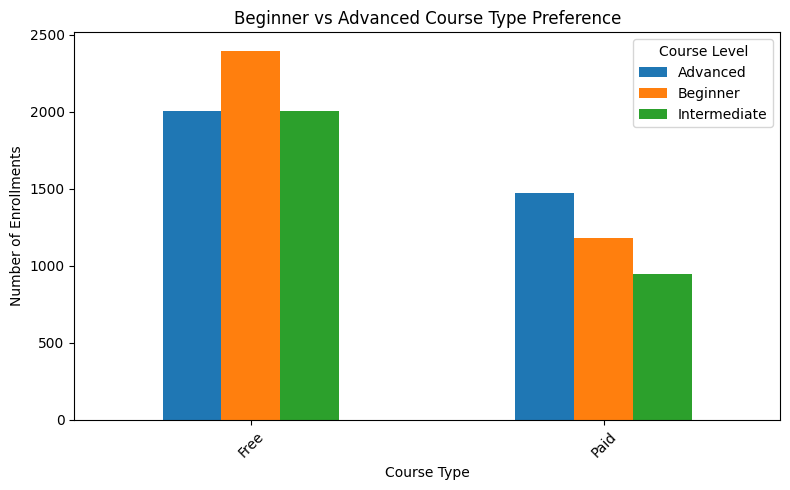

In [ ]:
#  Visualization - Course type preference

type_plot = pd.crosstab(
   df["CourseType"],
   df["CourseLevel"]
)

type_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Beginner vs Advanced Course Type Preference")
plt.xlabel("Course Type")
plt.ylabel("Number of Enrollments")
plt.xticks(rotation=45)
plt.legend(title="Course Level")
plt.tight_layout()
plt.show()

# **Key Performance Indicators (KPI Summary)**


In [108]:

# 1. TOTAL ENROLLMENTS
# Platform Engagement Indicator


total_enrollments = transactions["TransactionID"].nunique()




# 2. ENROLLMENTS BY AGE GROUP
# Demographic Reach


bins = [0, 18, 25, 35, 45, 55, 100]

labels = [
    "Below 18",
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "55+"
]

df["UserAgeGroup"] = pd.cut(
    df["UserAge"],
    bins=bins,
    labels=labels
)

enrollments_age = (
    df.groupby("UserAgeGroup", observed=True)
      .size()
      .reset_index(name="Enrollments")
)




# 3. GENDER PARTICIPATION RATIO
# Inclusivity Metric


gender_participation = (
    df["UserGender"]
    .value_counts()
    .reset_index()
)

gender_participation.columns = [
    "Gender",
    "Enrollments"
]

gender_participation["Participation_Ratio_%"] = (
    gender_participation["Enrollments"]
    / gender_participation["Enrollments"].sum()
    * 100
)



# 4. CATEGORY POPULARITY INDEX
# Course Demand


category_popularity = (
    df["CourseCategory"]
    .value_counts()
    .reset_index()
)

category_popularity.columns = [
    "CourseCategory",
    "Enrollments"
]

# Popularity Index
category_popularity["Popularity_Index_%"] = (
    category_popularity["Enrollments"]
    / category_popularity["Enrollments"].sum()
    * 100
)




# 5. LEVEL PREFERENCE DISTRIBUTION
# Skill Maturity Insight


level_preference = (
    df["CourseLevel"]
    .value_counts()
    .reset_index()
)

level_preference.columns = [
    "CourseLevel",
    "Enrollments"
]

level_preference["Preference_%"] = (
    level_preference["Enrollments"]
    / level_preference["Enrollments"].sum()
    * 100
)



# KPI SUMMARY


print("\n======================================")
print("       EDUPRO KPI SUMMARY")
print("======================================")

print("\n1. Total Enrollments:", total_enrollments)

print("\n2. Enrollments by Age Group:")
print(enrollments_age)

print("\n3. Gender Participation Ratio:")
print(gender_participation)

print("\n4. Category Popularity Index:")
print(category_popularity)

print("\n5. Level Preference Distribution:")
print(level_preference)


       EDUPRO KPI SUMMARY

1. Total Enrollments: 10000

2. Enrollments by Age Group:
  UserAgeGroup  Enrollments
0     Below 18         1946
1        18-25         3255
2        26-35         4799

3. Gender Participation Ratio:
   Gender  Enrollments  Participation_Ratio_%
0  Female         5078                  50.78
1    Male         4922                  49.22

4. Category Popularity Index:
             CourseCategory  Enrollments  Popularity_Index_%
0              Data Science          916                9.16
1                   Finance          864                8.64
2           Web Development          844                8.44
3                  Business          833                8.33
4   Artificial Intelligence          829                8.29
5        Project Management          829                8.29
6                    Design          827                8.27
7             Cybersecurity          819                8.19
8          Machine Learning          819            

In [109]:
# Save cleaned dataset for Streamlit dashboard

df.to_csv('edupro_cleaned.csv', index=False)

print("Cleaned dataset saved successfully!")
print("Shape:", df.shape)


Cleaned dataset saved successfully!
Shape: (10000, 25)
